In [21]:
# from google.colab import drive
# drive.mount('/content/drive')
# raiz="drive/MyDrive/proyecto_mineria/"
raiz=""

# Cargar datos y generar los conjuntos de entrenamiento y test

In [22]:
import pandas as pd
nombre_csv_logs="presentacion1_resultados.csv"
# file_path = 'data_set_limpio.pkl'
file_path = f'{raiz}datasets_pkl/data_set_limpio_sin_not_for_sale.pkl'

df = pd.read_pickle(file_path)

# Display the loaded DataFrame
print("shape: ",df.shape)
print(df.columns)
df.sample(n=5)


shape:  (186795, 70)
Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado'],
      dtype='object')


,Nat,Division,Club,Based,Preferred Foot,Right Foot,Left Foot,Position,Height,Weight,Age,Wage,AT Apps,AT Gls,Team,Caps,Yth Apps,Style,Rc Injury,Best Role,Best Duty,Best Pos,Acc,Aer,Agg,Agi,Ant,Bal,Bra,Cmd,Com,Cmp,Cnt,Cor,Cro,Dec,Det,Dri,Ecc,Fin,Fir,Fla,Fre,Han,Hea,Jum,Kic,Ldr,Lon,L Th,Mar,Nat .1,OtB,1v1,Pac,Pas,Pen,Pos,Pun,Ref,TRO,Sta,Str,Tck,Tea,Tec,Thr,Vis,Wor,transfer_value_estimado
73937,ROU,Italian Serie B,Pisa,Italy (Serie B),Right,Very Strong,Weak,D (C),188,84,26,15750,149,4,-,14,5,Physical,-,Central Defender,Defend,D (C),13,2,13,12,13,10,14,2,1,10,9,7,10,12,4,8,1,8,10,5,11,4,13,13,3,6,8,8,12,12,10,3,11,12,8,12,2,1,2,13,13,13,11,10,1,9,13,110000
40491,BRA,Brazilian National Second Division,ALA,Brazil (Second Division),Right,Very Strong,Reasonable,M/AM (C),172,65,20,170,0,0,-,0,0,Creative,-,Mezzala,Support,M (C),13,4,9,13,4,7,2,1,2,4,7,6,6,12,12,6,2,5,9,12,6,2,3,5,2,4,10,1,6,12,10,3,13,11,1,8,2,1,3,7,4,7,7,12,1,8,12,0
115764,GRE,Greek Super League 2 South,Irodotos,Greece (Super League 2 South),Right Only,Very Strong,Very Weak,"DM, M (C)",178,73,22,700,22,0,-,0,0,Technical,-,Central Midfielder,Attack,M (C),11,3,5,10,5,7,5,3,1,8,8,6,3,14,7,2,1,7,14,5,6,2,6,8,1,11,9,3,5,8,7,2,10,11,5,9,3,2,1,7,7,11,8,10,1,7,12,0
102542,BLR,Belarusian Second League,Krumkachy,Belarus (Second League),Right,Very Strong,Weak,D (C),178,66,18,180,0,0,-,0,0,Technical,-,Central Defender,Stopper,D (C),12,3,13,9,7,6,7,4,2,5,5,3,1,13,12,1,1,4,7,5,1,3,11,7,2,3,3,1,11,11,5,2,7,5,2,8,1,1,4,4,5,14,5,2,4,4,7,0
186896,ESP,Spanish Federation Third Group 5,Sant Andreu,Spain (Spanish Federation 3 Gr 5),Left,Weak,Very Strong,D/WB (L),175,69,27,875,139,1,-,0,0,Physical,-,Full-Back,Defend,D (L),13,1,10,10,7,8,9,4,2,5,10,4,4,14,14,1,2,6,10,9,2,1,5,8,3,6,1,7,8,16,7,3,11,9,4,8,1,2,1,12,7,12,8,8,3,7,8,30000


# Generar conjuntos de entrenamiento y test

In [23]:
import pandas as pd
import json
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error

def log_results(model, method_name, X_train, y_train, X_test, y_test,
                filepath=f"{raiz}{nombre_csv_logs}.csv"):
    params_dict = model.get_params()
    for k, v in params_dict.items():
        try:
            json.dumps(v)
        except TypeError:
            params_dict[k] = str(v)
    params = json.dumps(params_dict)

    y_pred = model.predict(X_test)

    r2_train = model.score(X_train, y_train)
    r2_test  = model.score(X_test,  y_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    row = {
        "method":          method_name,
        "hyperparameters": json.dumps(params),
        "r2_train":        r2_train,
        "r2_test":         r2_test,
        "mae":             mae,
        "rmse":            rmse
    }

    residuals = y_test - y_pred
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, bins=50, kde=True, color="blue")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.title("Residuals Distribution")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
             color='red', linestyle='--')
    plt.title("Regression Fit: Actual vs Predicted")
    plt.xlabel("Actual Transfer Values")
    plt.ylabel("Predicted Transfer Values")

    plt.suptitle(method_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"  R² train : {r2_train:.4f}")
    print(f"  R² test  : {r2_test:.4f}")
    print(f"  MAE      : {mae:.2f}")
    print(f"  RMSE     : {rmse:.2f}")

    try:
        df_log = pd.read_csv(filepath)
        df_log = pd.concat([df_log, pd.DataFrame([row])], ignore_index=True)
    except FileNotFoundError:
        df_log = pd.DataFrame([row])

    df_log.to_csv(filepath, index=False)

# Generar conjuntos de entrenamiento y test

In [24]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [25]:
import clustering as cl

kmeans_model_club = cl.fit_kmeans(train_df, columna="Club")
kmeans_model_nat = cl.fit_kmeans(train_df, columna="Nat")
kmeans_model_division = cl.fit_kmeans(train_df, columna="Division")


train_df = cl.apply_kmeans(train_df, kmeans_model_club)
train_df = cl.apply_kmeans(train_df, kmeans_model_nat)
train_df = cl.apply_kmeans(train_df, kmeans_model_division)

test_df = cl.apply_kmeans(test_df, kmeans_model_club)
test_df = cl.apply_kmeans(test_df, kmeans_model_nat)
test_df = cl.apply_kmeans(test_df, kmeans_model_division)



# Considerar solo las más importantes
Si previamente ejecutamos el algoritmo y ya tenemos el archivo

In [26]:
import json
target="transfer_value_estimado"
with open("importantes.json", "r") as f:
    cols_to_keep = json.load(f)
    
cols_to_keep.append(target)
train_df=train_df[cols_to_keep]
test_df=test_df[cols_to_keep]

In [27]:
drop_columns=["Club","Nat","Division",target]
X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target]

In [28]:
X_train.columns

Index(['Wage', 'Age', 'Based', 'Acc', 'Caps', 'Pac', 'Club_cluster', 'Cmp',
       'Dec', 'Str', 'Team', 'Bal', 'Dri', 'AT Gls', 'Tec', 'Tea', 'Mar',
       'Position', 'Height', 'AT Apps', 'Pen', 'Right Foot', 'L Th', 'Wor',
       'Han', 'Ant', 'Cor', 'Vis', 'Com', 'Preferred Foot', 'Yth Apps', 'Cro',
       'Fir', 'Best Pos', 'Ref', 'Jum', 'Aer', 'Pos', 'Nat_cluster',
       'Division_cluster'],
      dtype='object')

## One Hot para las features categóricas

In [29]:
# import numpy as np
# # categorical_cols=["Nat_cluster","Division_cluster","Club_cluster","Preferred Foot","Right Foot","Left Foot","Best Pos","Best Duty","Style","Best Role","Rc Injury"]
# categorical_cols=["Nat_cluster","Division_cluster","Best Duty","Style"]
# X_train = pd.get_dummies(X_train, columns=categorical_cols)
# X_test  = pd.get_dummies(X_test, columns=categorical_cols)

# X_train, X_test = X_train.align(X_test, join='left', axis=1,fill_value=0)

In [30]:
# X_train = X_train.select_dtypes(include=[np.number,np.bool_])
# X_test = X_test.select_dtypes(include=[np.number,np.bool_])

In [31]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train = pd.DataFrame(
#     scaler.fit_transform(X_train),
#     columns=X_train.columns,
#     index=X_train.index
# )

# X_test = pd.DataFrame(
#     scaler.transform(X_test),
#     columns=X_test.columns,
#     index=X_test.index
# )

In [32]:
print(X_train.shape)
print(X_test.shape)

(149436, 40)
(37359, 40)


# Entrenamiento

In [33]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Identify categorical columns
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Categorical columns: {cat_cols}")

# 2. Copy datasets
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# 3. Encode all categorical columns
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_encoded[cat_cols] = encoder.fit_transform(
    X_train[cat_cols]
)

X_test_encoded[cat_cols] = encoder.transform(
    X_test[cat_cols]
)

# 4. Train model
model = HistGradientBoostingRegressor()

# 

Categorical columns: ['Based', 'Team', 'Position', 'Right Foot', 'Preferred Foot', 'Best Pos']


# Entrenamiento y Evaluación

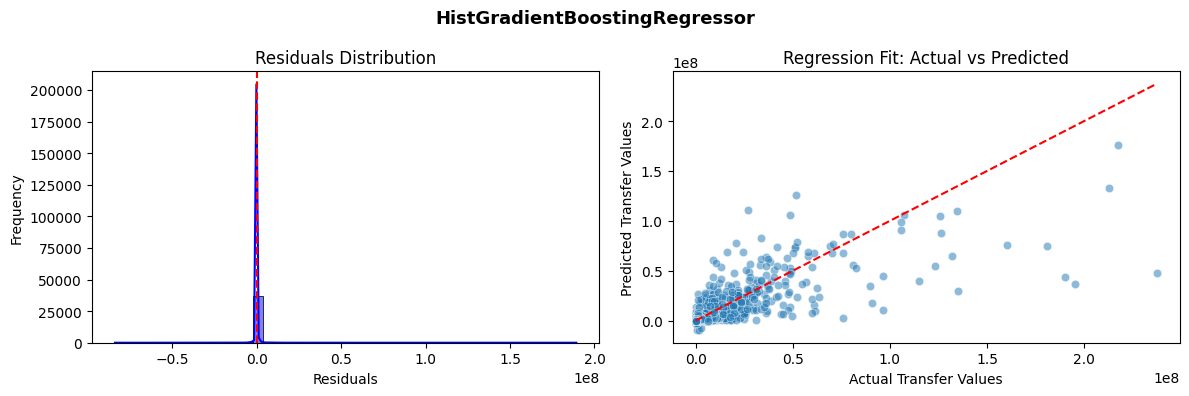

  R² train : 0.8377
  R² test  : 0.6307
  MAE      : 347707.45
  RMSE     : 2721201.89


In [34]:
model.fit(X_train_encoded, y_train)
# model.fit(X_train_encoded, y_train)

# # 5. Predict
preds = model.predict(X_test_encoded)
log_results(model,"HistGradientBoostingRegressor",X_train_encoded,y_train,X_test_encoded,y_test,filepath=nombre_csv_logs)

In [35]:
preds = model.predict(X_test_encoded)
print("saco ",model.score(X_test_encoded,y_test))
preds

saco  0.6306871759163679


array([284991.64769752,  27987.5814932 ,  49657.8943115 , ...,
        39572.02475655,  45890.42450969,  78401.57552281], shape=(37359,))

# Feature importance

In [36]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model,          # trained HistGradientBoostingRegressor
    X_test_encoded,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": X_test_encoded.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

print(importance_df)

             feature  importance_mean  importance_std
0               Wage    415363.945141     3277.346192
1                Age    187928.743277     6180.778142
2              Based     14028.881561     1370.265995
6       Club_cluster      5845.059706      110.818670
5                Pac      5539.473513      979.532535
3                Acc      4609.863393     1278.116189
8                Dec      4528.060246     1381.937284
7                Cmp      3509.973225      794.120671
10              Team      3242.720077      957.685270
25               Ant      2931.016840      520.732933
16               Mar      2733.145325     1415.089722
27               Vis      2262.810370      764.836592
14               Tec      1798.518680      365.937723
37               Pos      1465.926023      529.538522
32               Fir      1445.788946      312.509418
34               Ref      1216.003979      285.716656
11               Bal      1146.943438      259.661390
18            Height      11

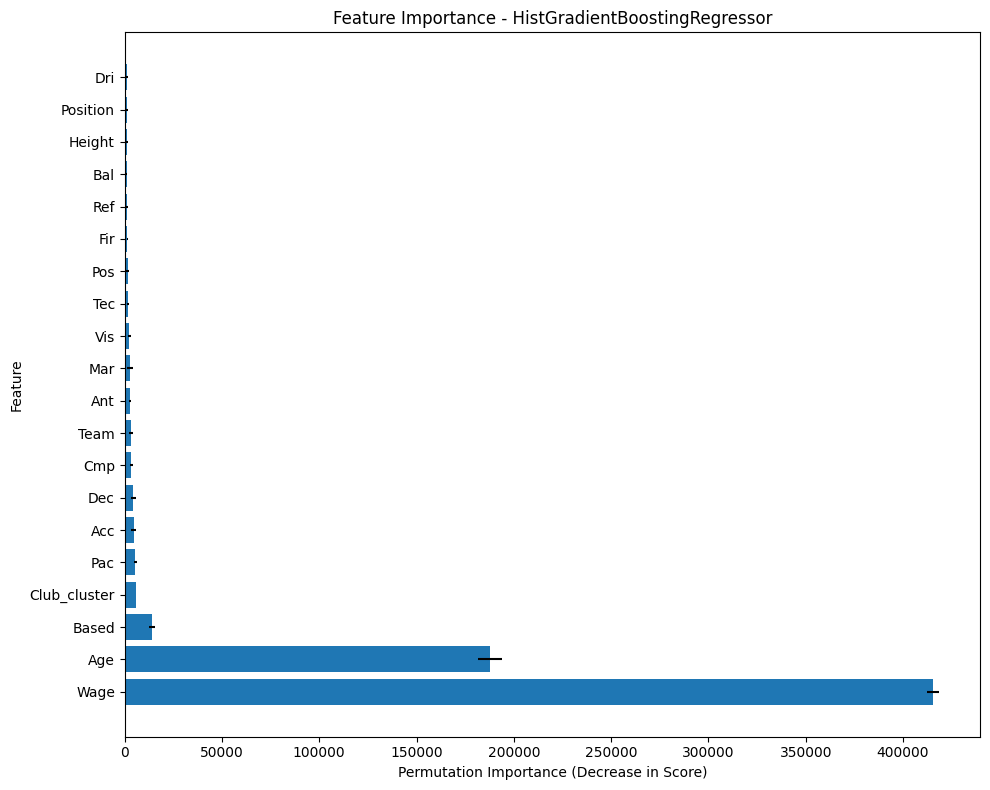

In [37]:
import matplotlib.pyplot as plt

# Optional: keep only top N features
top_n = 20
plot_df = importance_df.head(top_n)

# Create figure
plt.figure(figsize=(10, 8))

# Horizontal bar plot
plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)

# Labels and title
plt.xlabel("Permutation Importance (Decrease in Score)")
plt.ylabel("Feature")
plt.title("Feature Importance - HistGradientBoostingRegressor")

# Highest importance at top
# plt.gca().invert_yaxis()

# Better spacing
plt.tight_layout()

# Show plot
plt.show()

In [38]:
import pandas as pd
visualizar_todo=True
if visualizar_todo:
    # Show all rows
    pd.set_option('display.max_rows', None)

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Show full content of each cell (prevent text truncation)
    pd.set_option('display.max_colwidth', None)

print(importance_df)

             feature  importance_mean  importance_std
0               Wage    415363.945141     3277.346192
1                Age    187928.743277     6180.778142
2              Based     14028.881561     1370.265995
6       Club_cluster      5845.059706      110.818670
5                Pac      5539.473513      979.532535
3                Acc      4609.863393     1278.116189
8                Dec      4528.060246     1381.937284
7                Cmp      3509.973225      794.120671
10              Team      3242.720077      957.685270
25               Ant      2931.016840      520.732933
16               Mar      2733.145325     1415.089722
27               Vis      2262.810370      764.836592
14               Tec      1798.518680      365.937723
37               Pos      1465.926023      529.538522
32               Fir      1445.788946      312.509418
34               Ref      1216.003979      285.716656
11               Bal      1146.943438      259.661390
18            Height      11

In [39]:
genera_json=False
if genera_json:
    importantes=importance_df.loc[importance_df["importance_mean"] >= 0, "feature"].unique()
    importantes=importantes.tolist()
    import json

    with open("importantes.json", "w") as f:
        json.dump(importantes, f)


# Evaluar modelo con gente "barata"

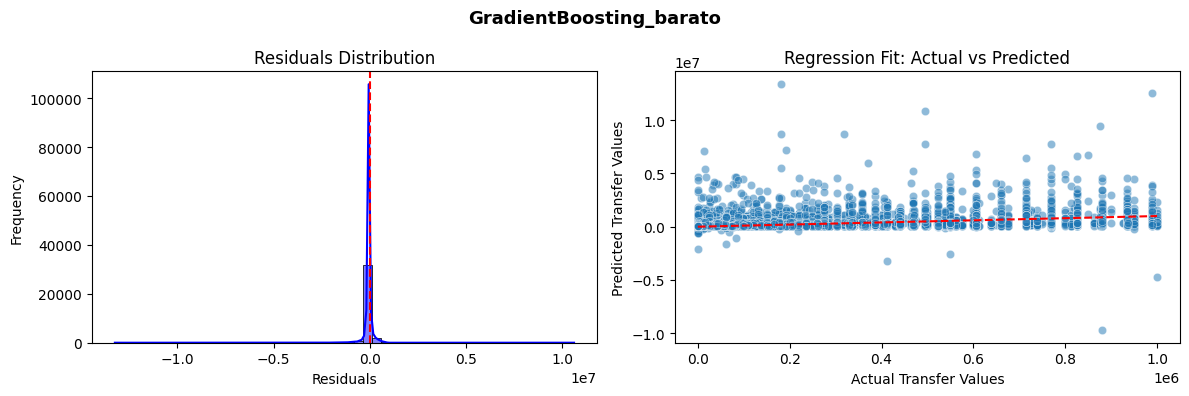

  R² train : 0.8377
  R² test  : -2.5849
  MAE      : 123140.55
  RMSE     : 333464.07


In [48]:
mask = y_test <= 1e6

X_test_barato = X_test_encoded[mask]
y_test_barato = y_test[mask]
log_results(model,"GradientBoosting_barato",X_train_encoded,y_train,X_test_barato,y_test_barato,filepath=nombre_csv_logs)